[17:01:02] (load_picam_data) Loading PiCamera data for experiment 20250226_e01

[17:01:02] (find_picams) 2 picamera(s) found: ['pic1', 'pic2']

[17:01:02] (load_picam_metadata) pic1 metadata loaded!
[17:01:02] (load_picamera_clock_data) pic1 frame time data loaded!
[17:01:02] (load_picam_LED_data) LED intensity values loaded!

[17:01:02] (load_picam_metadata) pic2 metadata loaded!
[17:01:02] (load_picamera_clock_data) pic2 frame time data loaded!
[17:01:02] (load_picam_LED_data) LED intensity values loaded!

[17:01:02] (load_picam_data) PiCamera Acquisition SUMMARY:

   Metadata (pic1):
   Framerate [fps]: 40.0
   Video duration [min]: 1.0
   Resolution [px]: (1280, 720)
   Shutter speed [us]: 3000.0
   Bitrate [bit/sec]: 7000000

   Metadata (pic2):
   Framerate [fps]: 40.0
   Video duration [min]: 1.0
   Resolution [px]: (1280, 720)
   Shutter speed [us]: 3000.0
   Bitrate [bit/sec]: 7000000


[17:01:02] (analyze_picam_times) Analyzing picam frame times for experiment 20250226_e01:



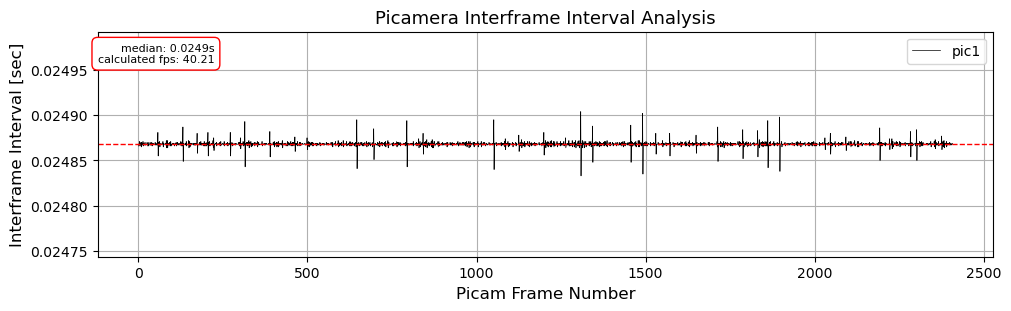


Frame analysis for pic2:
   Total number of picam frames found: 2408
   Total number of dropped picam frames: 0


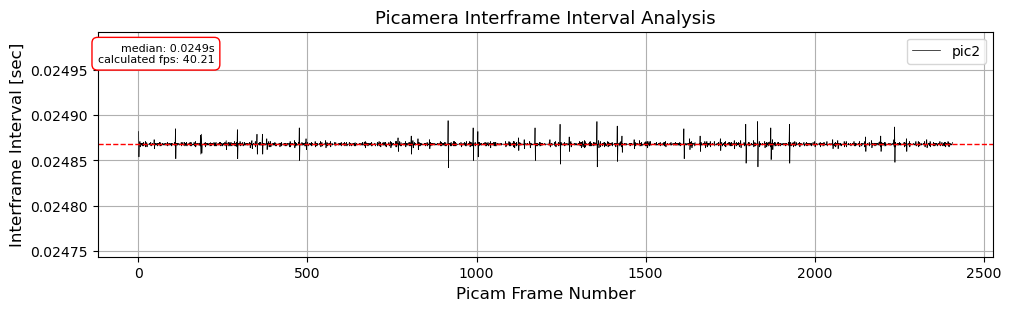


[17:01:02] (analyze_picam_times) Analysis of picam frame timing completed for experiment 20250226_e01.


[17:01:02] (load_daq_data) Loading DAQ data for experiment 20250226_e01

[17:01:02] (load_daq_data) Loaded: daq_arduino_voltage.csv

-------------------------------------------------------------------------------------------------------------

[17:01:03] (synchronize_daq_picameras) Synchronizing DAQ and PiCamera data for experiment 20250226_e01
                                   using ROI intensity-voltage matching of the same blinking LED.

[17:01:03] (initialize_sync_dict) Calculate lag between DAQ signal and pic1 using cross-correlation.
[17:01:03] (determine_picam_daq_drift_and_plot) 197 Edge-Blink pairs found for pic1.
[17:01:03] (find_outliers_regression) 0 outlier Edge-Blink pairs found and replaced for pic1 
                                      using a time difference threshold of ±30.00 msecs!

[17:01:03] (determine_picam_daq_drift_and_plot) pic1 slope:     -0.000014
    

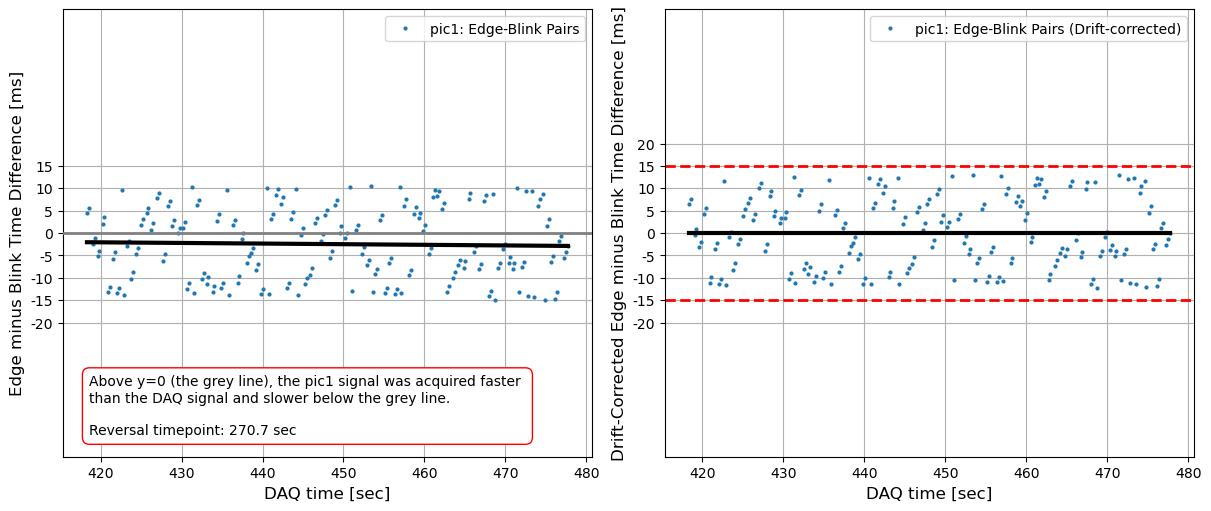


[17:01:03] (initialize_sync_dict) Calculate lag between DAQ signal and pic2 using cross-correlation.
[17:01:03] (determine_picam_daq_drift_and_plot) 197 Edge-Blink pairs found for pic2.
[17:01:03] (find_outliers_regression) 0 outlier Edge-Blink pairs found and replaced for pic2 
                                      using a time difference threshold of ±30.00 msecs!

[17:01:03] (determine_picam_daq_drift_and_plot) pic2 slope:     -0.000003
                                                pic2 intercept:  0.001324



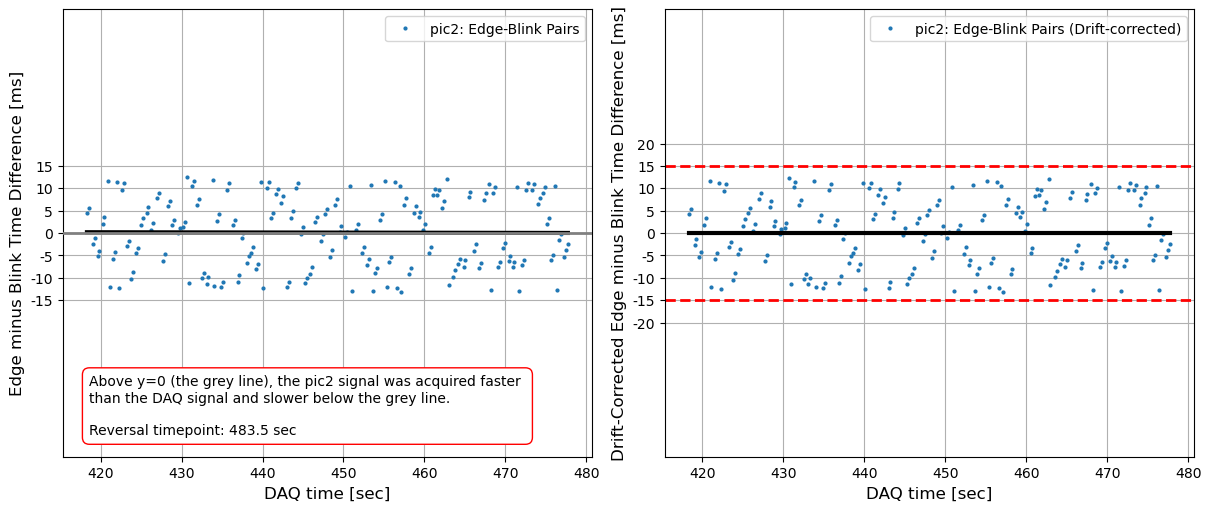


[17:01:03] (synchronize_daq_picameras) PiCamera-DAQ synchronization SUMMARY:

            pic1-DAQ lag (sec): 65.4900
            pic2-DAQ lag (sec): 65.4900
            lagPicam1-lagPicam2 (sec): 0.0000


In [1]:
# Standard library imports
import getpass
import matplotlib.pyplot as plt

from synchronization_modules import picam_data_loader
from synchronization_modules import picam_data_analysis
from synchronization_modules import daq_data_loader
from synchronization_modules import sync_daq_picam 

user = getpass.getuser()
# datadir    = '/home/' + user + '/Desktop/picam_sync_neuro/testdata/'
datadir    = '/media/' + user + '/DATA/picam_sync_neuro/testdata/'

expID      = '20250226_e01'

picam_dict = picam_data_loader.load_picam_data(datadir, expID, verbose=True)
picam_dict = picam_data_analysis.analyze_picam_times(datadir, expID, picam_dict, verbose=True)

daq_dict = daq_data_loader.load_daq_data(datadir, expID, daq_frequency=3000)

sync_dict = sync_daq_picam.synchronize_daq_picameras(datadir, expID, picam_dict, daq_dict, verbose=True)

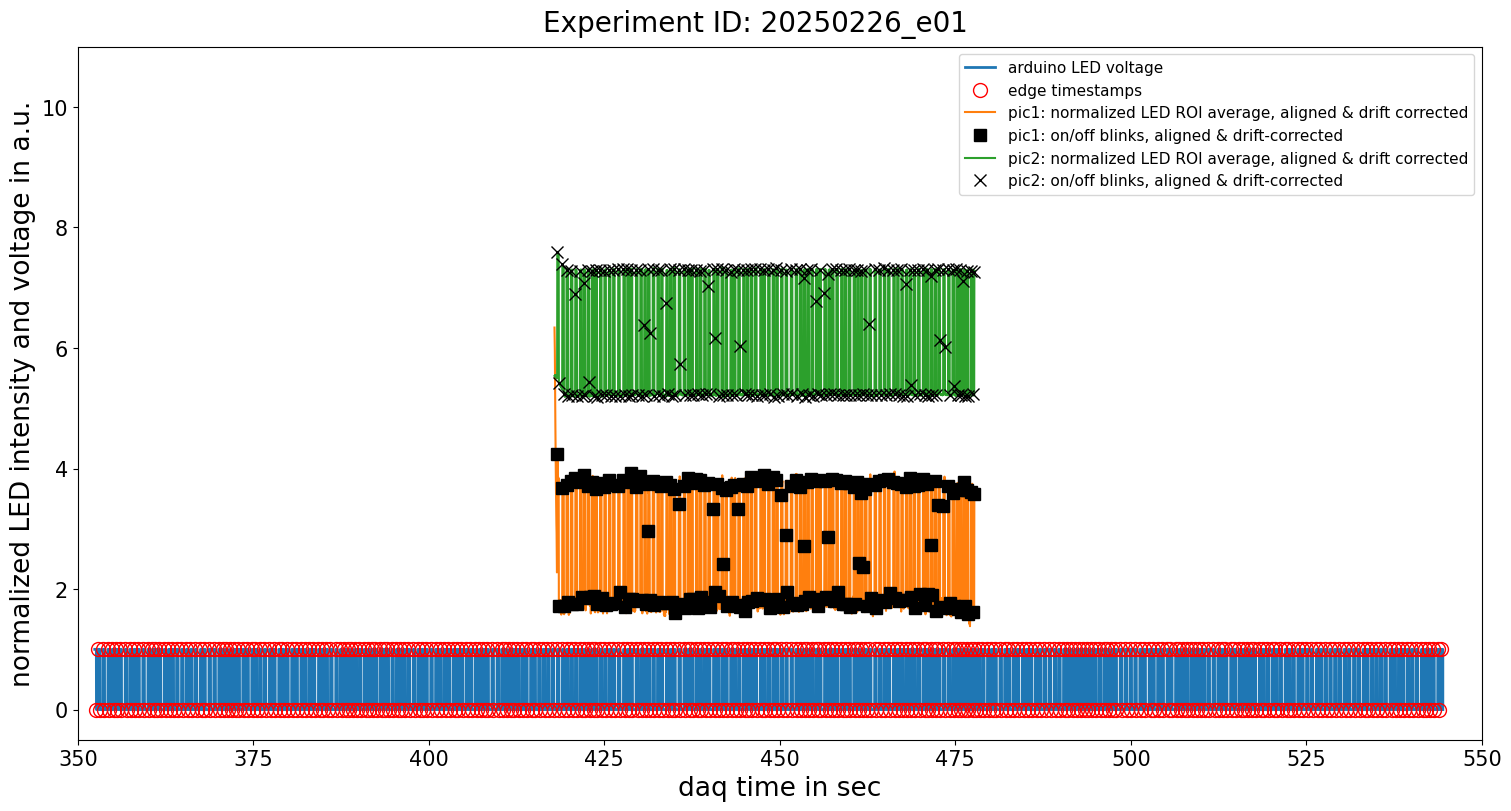

In [2]:
sync_daq_picam.plot_picam_daq_sync_data(datadir, expID, picam_dict, daq_dict, sync_dict, xmin=350, xmax=550)

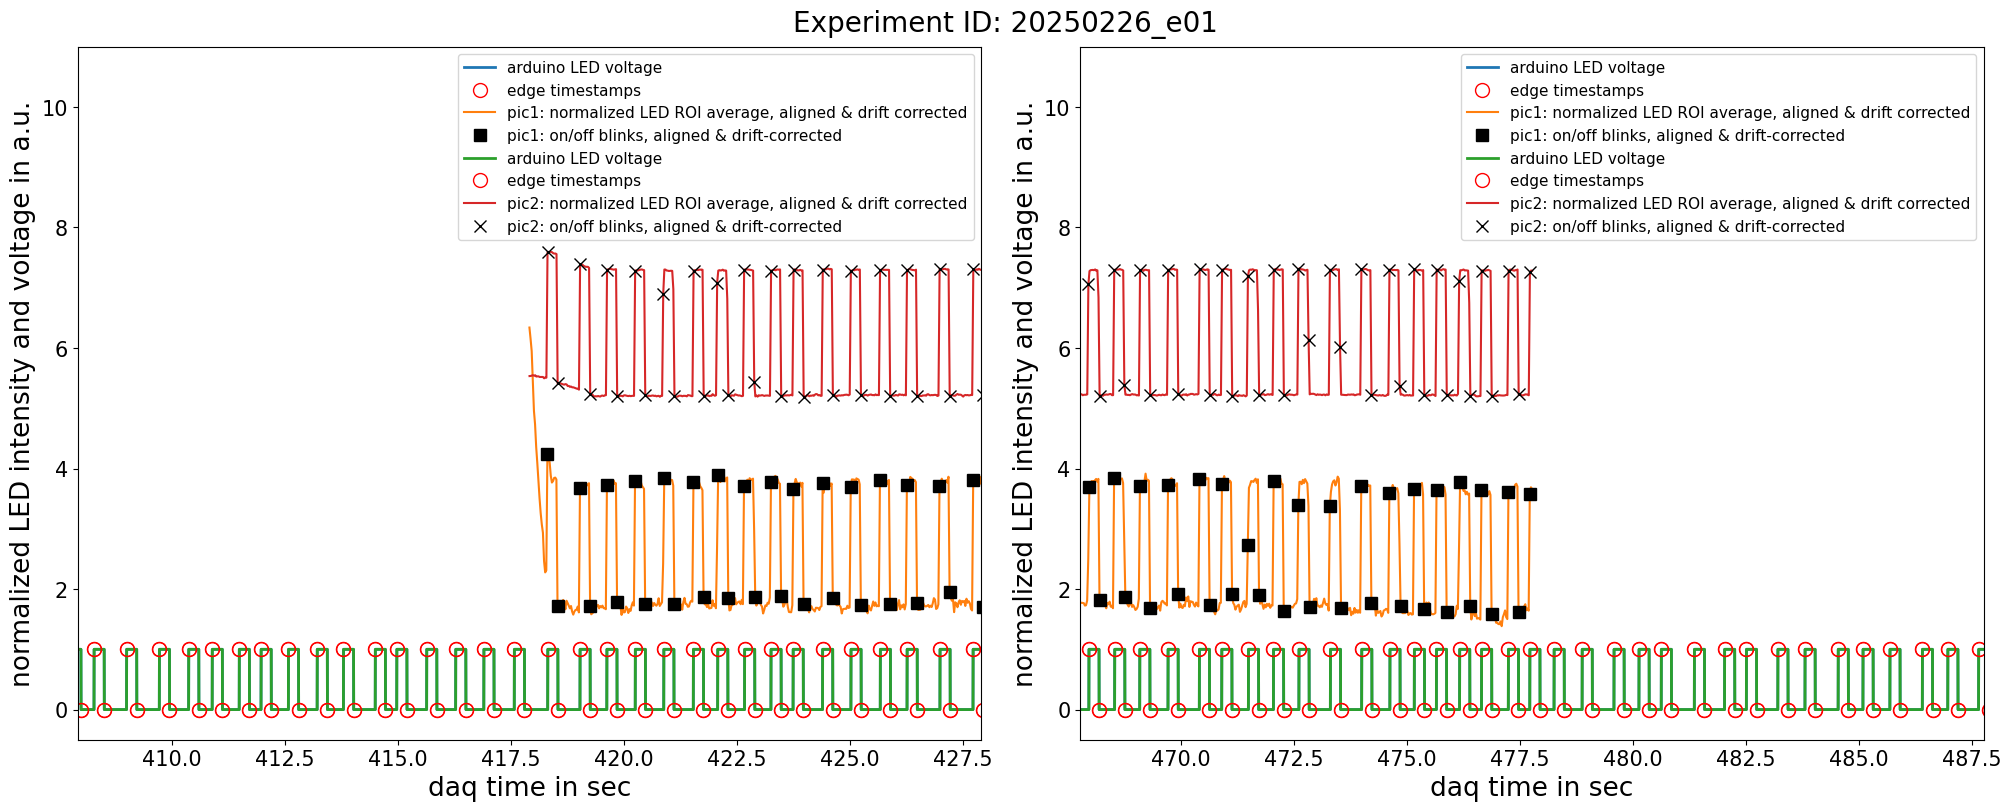

In [4]:
sync_daq_picam.plot_picam_daq_sync_data2(datadir, expID, picam_dict, daq_dict, sync_dict)